# Density & Power Study -- Part 1: Spacing vs. Turbine Choice

Geometric study (no wake/AEP simulation) of what actually drives capacity density (PD, MW/km2) in the MA/RI cluster: turbine model choice or inter-turbine spacing. Two scenarios are compared -- a real, not-yet-built lease with a declared turbine count (SouthCoast Wind), and a speculative case with no real boundary, sized only to a capacity target. Results inform which variables the Monte Carlo sampling should treat as independent axes.

In [ ]:

# ENVIRONMENT CHECK -- run this first. Installs/upgrades this kernel's
# environment to the exact package versions this notebook was tested with.
# ===============================
import importlib.metadata 
import subprocess
import sys

REQUIRED = {
    "numpy": "2.3.2", "scipy": "1.17.1", "matplotlib": "3.10.6", "xarray": "2025.1.0",
    "shapely": "2.1.2", "pyproj": "3.7.0", "openmdao": "3.40.0", "windIO": "2.1.1",
    "py_wake": "2.6.20", "optiwindnet": "0.3.0", "ortools": "9.15.6755",
    "h5py": "3.16.0", "netCDF4": "1.7.4", "openturns": "1.27.post1", "scikit-learn": "1.9.0",
}

def installed(pkg):
    try:
        return importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        return None

mismatched = {p: v for p, v in REQUIRED.items() if installed(p) != v}

if mismatched:
    print(f"Installing {len(mismatched)} package(s) to the versions this notebook was tested with...")
    for pkg, version in mismatched.items():
        print(f"  {pkg}=={version} ...")
        result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', f'{pkg}=={version}'],
                                 capture_output=True, text=True)
        if result.returncode != 0:
            print(result.stdout[-2000:])
            print(result.stderr[-2000:])
            raise RuntimeError(
                f"Could not install '{pkg}=={version}' automatically. Install it manually in this "
                f"kernel's environment (`{sys.executable} -m pip install {pkg}=={version}`) and re-run "
                f"this cell.")
    importlib.metadata.invalidate_caches()

print("Environment OK -- all versions match what this notebook was tested with.")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
import windIO
from pathlib import Path
from shapely.geometry import Point, Polygon

DATA_DIR = Path("..") / ".." / "Data"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Deployment targets

The U.S. offshore wind pipeline currently totals more than 80 GW under regulatory review, with state procurement goals exceeding 115 GW (Fuchs et al. 2024). The same report's Table 8 projects global fixed-bottom deployment under three scenarios, at a global conservative:mid:advanced ratio of roughly 1 : 2.5 : 4 by 2035. It also uses 1 GW as the representative plant size for national-scale cost modeling -- the same value used below as the capacity target in Case 2.

Fuchs, R. et al. (2024). *The Cost of Offshore Wind Energy in the United States From 2025 to 2050.* NREL/TP-5000-88988.

![NREL Table 8](figures/NRL_Table8.png)

![NREL section 2.3.1](figures/STUDY_SCOPE_NRL.png)

## 2. Spacing

Two reference values anchor the spacing range used in this study: 7D, the generic default used both in the current pipeline and in NREL's own national FLORIS study, and the spacing actually observed at the four farms in this cluster with a real, built layout (Vineyard Wind, Revolution Wind, South Fork Wind, and Sunrise Wind South), computed below in 2.1.

### 2.1 Observed spacing at as-built farms

In [2]:
BOUNDARY_INDEX = {"Vineyard Wind": 0, "Revolution Wind": 1, "South Fork Wind": 3, "Sunrise Wind South": 4}

wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")
site_us = windIO.load_yaml(DATA_DIR / "site_us.yaml")
boundary_polygons = site_us["boundaries"]["polygons"]
farms_by_name = {f["name"]: f for f in wind_farm_us}

def plot_observed_spacing(farm_name, fname):
    farm = farms_by_name[farm_name]
    x = np.array(farm["layouts"][0]["coordinates"]["x"])
    y = np.array(farm["layouts"][0]["coordinates"]["y"])
    D = farm["turbines"]["rotor_diameter"]
    boundary = boundary_polygons[BOUNDARY_INDEX[farm_name]]

    nn = np.array([np.delete(np.hypot(x - xi, y - yi), i).min() for i, (xi, yi) in enumerate(zip(x, y))])
    spacing_m = np.median(nn)

    fig, ax = plt.subplots(figsize=(6, 6))
    bx, by = boundary["x"], boundary["y"]
    ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "--", color="gray", linewidth=0.8)
    ax.scatter(x / 1000, y / 1000, s=16, color="#1B6E86")
    ax.set_title(f"{farm_name}\n{farm['turbines']['name']}, D={D:.0f}m, n={len(x)}\n"
                 f"median spacing = {spacing_m:.0f}m = {spacing_m/D:.2f}D")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_aspect("equal")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / fname, dpi=180, bbox_inches="tight")
    plt.show()

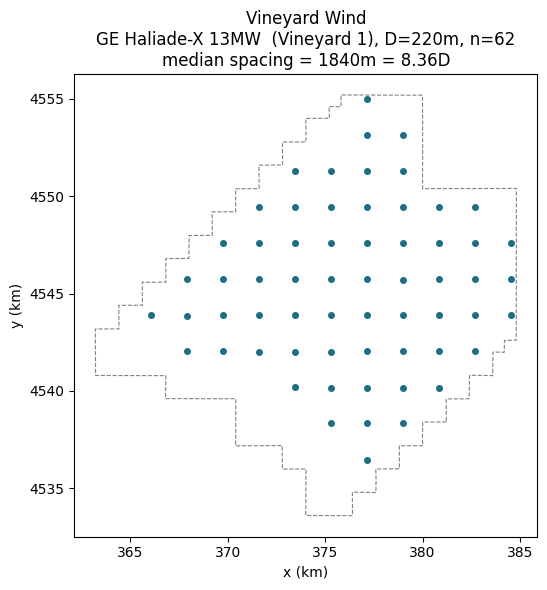

In [3]:
plot_observed_spacing("Vineyard Wind", "observed_spacing_vineyard.png")

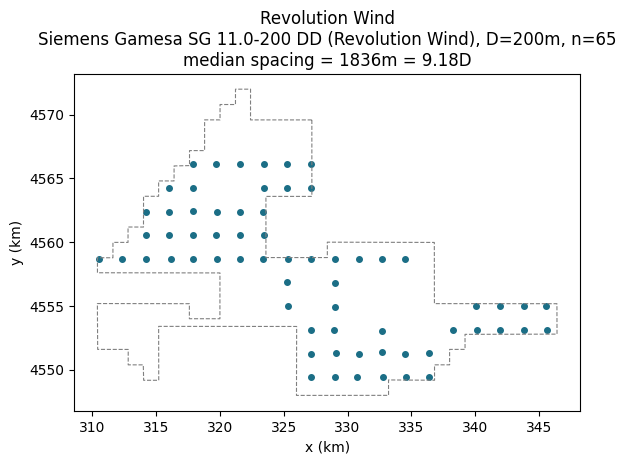

In [4]:
plot_observed_spacing("Revolution Wind", "observed_spacing_revolution.png")

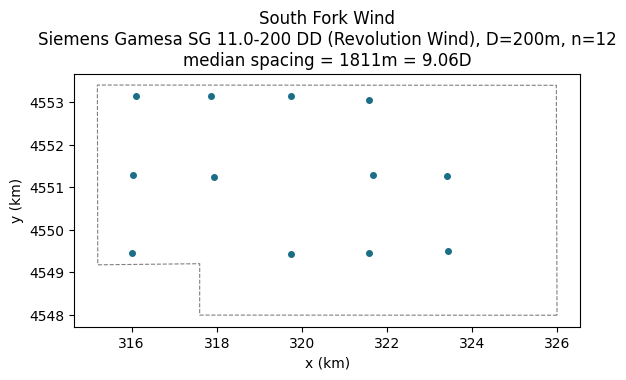

In [5]:
plot_observed_spacing("South Fork Wind", "observed_spacing_southfork.png")

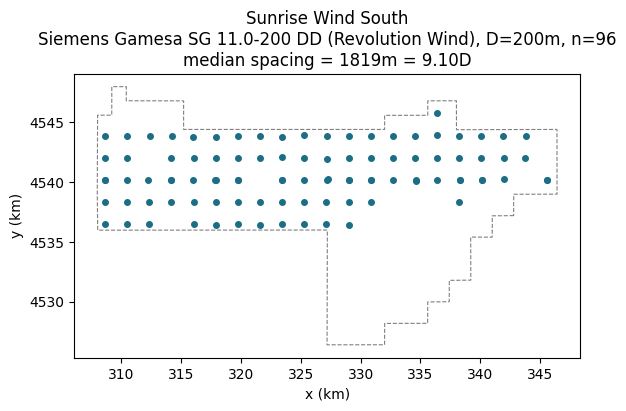

In [6]:
plot_observed_spacing("Sunrise Wind South", "observed_spacing_sunrise_south.png")

## 3. Turbine models available

Four candidate turbines are defined as individual WindIO YAML files in `Data/`: GE Haliade-X 13MW (220m), GE Haliade-X 15.5MW (250m), GWH300 22MW (300m), and the DTU 10MW Reference Wind Turbine (178.3m). This study sweeps three of them -- 13MW, 15.5MW, and DTU10MW -- leaving the 22MW option out of today's plan.

In [7]:
def load_turbine(fname):
    with open(DATA_DIR / fname) as f:
        d = yaml.safe_load(f)
    return dict(diameter=d["rotor_diameter"], rated_mw=d["performance"]["rated_power"] / 1e6)

TURBINES = {
    "Haliade-X 13MW": load_turbine("haliadex_13mw.yaml"),
    "Haliade-X 15.5MW": load_turbine("haliadex_15.5.yaml"),
    "DTU10MW": load_turbine("dtu10mw.yaml"),
}
COLORS = {"Haliade-X 13MW": "#1B6E86", "Haliade-X 15.5MW": "#2E8CA6", "DTU10MW": "#C17A1F"}
SPACING_D_RANGE = np.arange(5.0, 12.5, 0.5)

for name, spec in TURBINES.items():
    print(f"{name}: {spec['rated_mw']:.2f} MW, D={spec['diameter']:.1f} m")

Haliade-X 13MW: 13.00 MW, D=220.0 m
Haliade-X 15.5MW: 15.50 MW, D=250.0 m
DTU10MW: 10.04 MW, D=178.3 m


## 4. Case 1 -- SouthCoast Wind (lease not yet built)

SouthCoast Wind has a real, fixed lease boundary and a declared turbine count of 141, as listed on the public Sea Impact offshore wind map. No layout has been published yet. Every plot below is self-contained -- SouthCoast's own turbines only, no neighboring farm -- since this section studies SouthCoast's own density and delivered power, not its effect on anyone else.

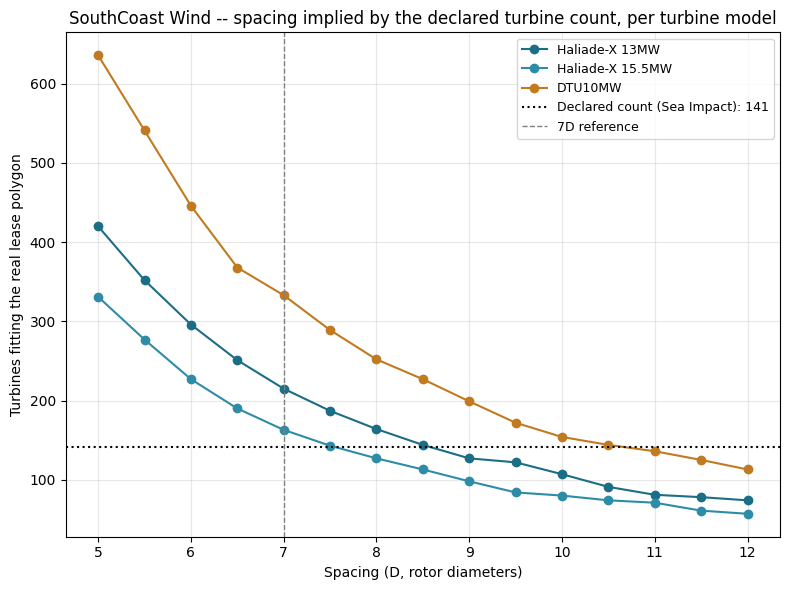

In [8]:
SOUTHCOAST_DECLARED_TURBINES = 141
southcoast_polygon = Polygon(zip(boundary_polygons[2]["x"], boundary_polygons[2]["y"]))
southcoast_area_km2 = southcoast_polygon.area / 1e6

def grid_fill_count(polygon, diameter, spacing_d):
    spacing = spacing_d * diameter
    xmin, ymin, xmax, ymax = polygon.bounds
    xs = np.arange(xmin, xmax + spacing, spacing)
    ys = np.arange(ymin, ymax + spacing, spacing)
    return sum(1 for x in xs for y in ys if polygon.contains(Point(x, y)))

def grid_fill_points(polygon, diameter, spacing_d):
    spacing = spacing_d * diameter
    xmin, ymin, xmax, ymax = polygon.bounds
    xs = np.arange(xmin, xmax + spacing, spacing)
    ys = np.arange(ymin, ymax + spacing, spacing)
    return np.array([(x, y) for x in xs for y in ys if polygon.contains(Point(x, y))])

fig, ax = plt.subplots(figsize=(8, 6))
for name, spec in TURBINES.items():
    counts = [grid_fill_count(southcoast_polygon, spec["diameter"], sd) for sd in SPACING_D_RANGE]
    ax.plot(SPACING_D_RANGE, counts, "o-", color=COLORS[name], label=name)

ax.axhline(SOUTHCOAST_DECLARED_TURBINES, color="black", linestyle=":", label="Declared count (Sea Impact): 141")
ax.axvline(7.0, color="gray", linestyle="--", linewidth=1, label="7D reference")
ax.set_xlabel("Spacing (D, rotor diameters)")
ax.set_ylabel("Turbines fitting the real lease polygon")
ax.set_title("SouthCoast Wind -- spacing implied by the declared turbine count, per turbine model")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "case1_southcoast_declared_capacity.png", dpi=180, bbox_inches="tight")
plt.show()

### 4.1 Wake field at the 7D reference

SouthCoast's own turbines, wake-simulated in isolation -- no neighboring farm. Wind from the predominant sector of the real 24-year mean rose (210 deg, SSW), 10 m/s.

In [9]:
from py_wake.wind_turbines import WindTurbine, WindTurbines
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake.site import UniformWeibullSite
from py_wake.literature.turbopark import Nygaard_2022
from py_wake.flow_map import HorizontalGrid

def build_pywake_turbine(fname):
    with open(DATA_DIR / fname) as f:
        d = yaml.safe_load(f)
    pc = d["performance"]["power_curve"]
    ctc = d["performance"]["Ct_curve"]
    return WindTurbine(name=d["name"], diameter=d["rotor_diameter"], hub_height=d["hub_height"],
                        powerCtFunction=PowerCtTabular(ws=pc["power_wind_speeds"], power=pc["power_values"],
                                                        power_unit="W", ct=ctc["Ct_values"]))

energy_resource = windIO.load_yaml(DATA_DIR / "energy_resource_us.yaml")["wind_resource"]
site = UniformWeibullSite(p_wd=energy_resource["sector_probability"]["data"],
                           a=energy_resource["weibull_a"]["data"],
                           k=energy_resource["weibull_k"]["data"], ti=0.06)

SIM_WD = np.arange(0, 360, 30)
SIM_WS = np.arange(3, 26, 1)
DOMINANT_WD = 210
TURBINE_FILES = {"Haliade-X 13MW": "haliadex_13mw.yaml", "Haliade-X 15.5MW": "haliadex_15.5.yaml", "DTU10MW": "dtu10mw.yaml"}

def compute_self_aep(x, y, turbine_obj):
    single_type = WindTurbines.from_WindTurbine_lst([turbine_obj])
    wfm = Nygaard_2022(site, single_type)
    return wfm(list(x), list(y), wd=SIM_WD, ws=SIM_WS).aep().sum().values, wfm

def plot_case1_wake(name, spec, fname):
    pts = grid_fill_points(southcoast_polygon, spec["diameter"], 7.0)
    turbine_obj = build_pywake_turbine(TURBINE_FILES[name])
    _, wfm = compute_self_aep(pts[:, 0], pts[:, 1], turbine_obj)
    sim_snap = wfm(list(pts[:, 0]), list(pts[:, 1]), wd=[DOMINANT_WD], ws=[10])
    fmap = sim_snap.flow_map(grid=HorizontalGrid(resolution=300))

    fig, ax = plt.subplots(figsize=(8, 8))
    fmap.plot_wake_map(ax=ax, cmap="inferno", normalize_with=1000, plot_windturbines=False)
    bx, by = boundary_polygons[2]["x"], boundary_polygons[2]["y"]
    ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "--", color="white", linewidth=1.0)
    ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=6, color="white", edgecolor="black", linewidth=0.15)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(f"{name} @ 7D -- {len(pts)} turbines (declared target: {SOUTHCOAST_DECLARED_TURBINES})\nwind from {DOMINANT_WD} deg")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / fname, dpi=180, bbox_inches="tight")
    plt.show()

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


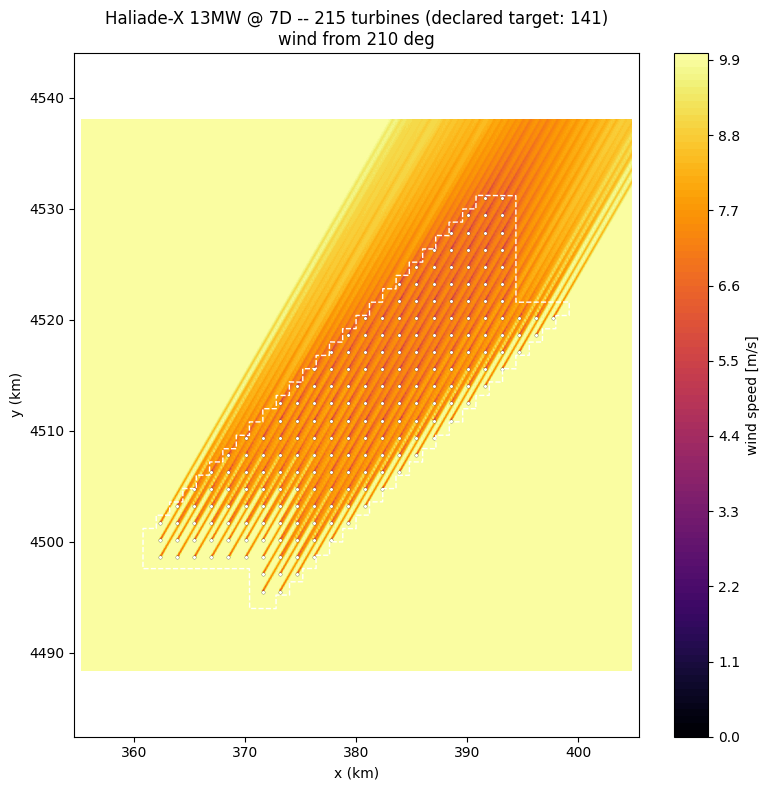

In [10]:
plot_case1_wake("Haliade-X 13MW", TURBINES["Haliade-X 13MW"], "case1_wake_7d_haliade13.png")

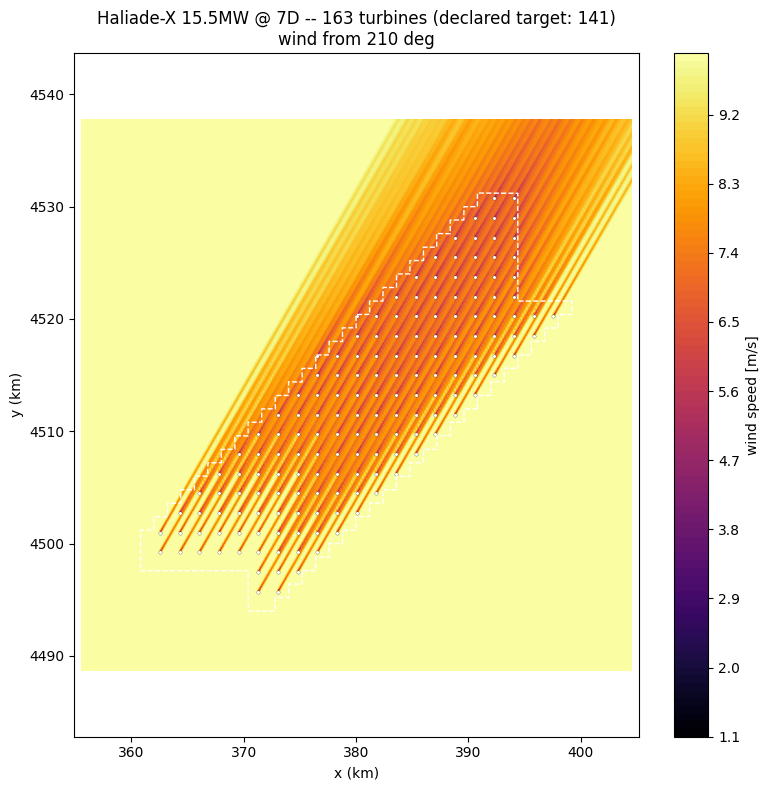

In [11]:
plot_case1_wake("Haliade-X 15.5MW", TURBINES["Haliade-X 15.5MW"], "case1_wake_7d_haliade155.png")

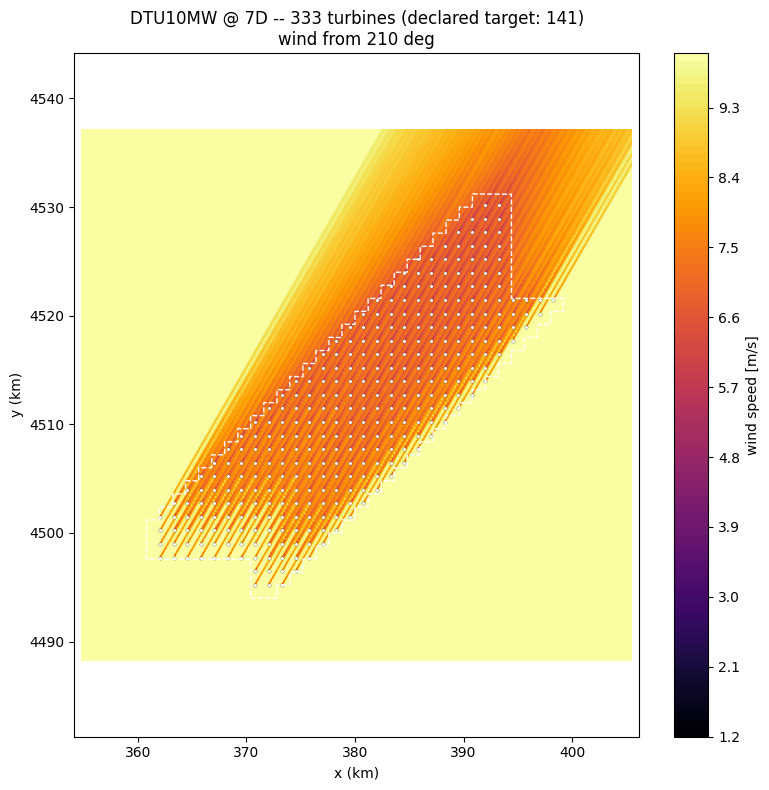

In [12]:
plot_case1_wake("DTU10MW", TURBINES["DTU10MW"], "case1_wake_7d_dtu10mw.png")

### 4.2 Density power vs. spacing -- nominal vs. delivered

Nominal power density (MW/km2, pure geometry) compared against delivered power density (MW/km2, average -- SouthCoast's own wake-simulated AEP converted to an average MW output, still no neighboring farm). Same units on both panels, so they are directly comparable, and the ratio between them at any spacing is the effective net capacity factor of that configuration. If the two panels have the same shape, geometry alone is a fair proxy; where they diverge, internal self-wake losses at tight spacing are changing the picture.

In [13]:
density_results = {name: {"nominal": [], "delivered": []} for name in TURBINES}
for name, spec in TURBINES.items():
    turbine_obj = build_pywake_turbine(TURBINE_FILES[name])
    for sd in SPACING_D_RANGE:
        pts = grid_fill_points(southcoast_polygon, spec["diameter"], sd)
        nominal_mw_km2 = len(pts) * spec["rated_mw"] / southcoast_area_km2
        aep_gwh, _ = compute_self_aep(pts[:, 0], pts[:, 1], turbine_obj)
        avg_power_mw = aep_gwh * 1000 / 8760
        delivered_mw_km2 = avg_power_mw / southcoast_area_km2
        density_results[name]["nominal"].append(nominal_mw_km2)
        density_results[name]["delivered"].append(delivered_mw_km2)
    print(f"{name}: done")

Haliade-X 13MW: done


Haliade-X 15.5MW: done


DTU10MW: done


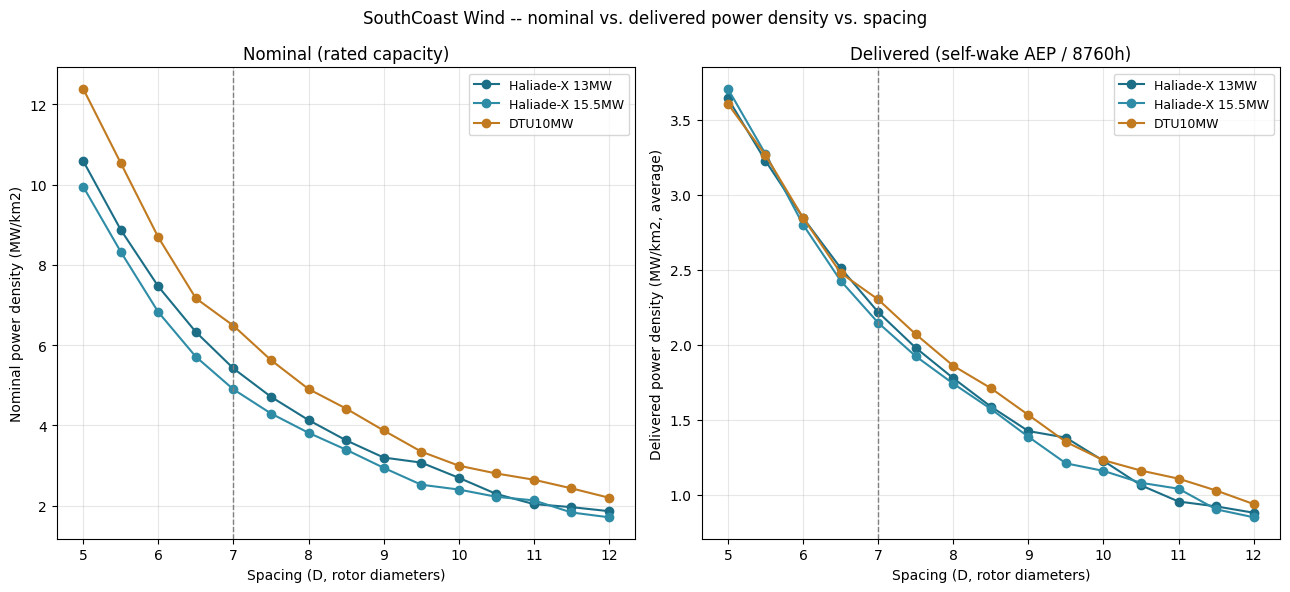

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for name in TURBINES:
    axes[0].plot(SPACING_D_RANGE, density_results[name]["nominal"], "o-", color=COLORS[name], label=name)
    axes[1].plot(SPACING_D_RANGE, density_results[name]["delivered"], "o-", color=COLORS[name], label=name)

for ax, ylabel, title in zip(axes, ["Nominal power density (MW/km2)", "Delivered power density (MW/km2, average)"],
                              ["Nominal (rated capacity)", "Delivered (self-wake AEP / 8760h)"]):
    ax.axvline(7.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Spacing (D, rotor diameters)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("SouthCoast Wind -- nominal vs. delivered power density vs. spacing")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "case1_nominal_vs_delivered_density.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Case 2 -- speculative capacity target

No real lease exists for this case. A new farm is instead sized to a fixed capacity target of 1 GW, the representative plant size used in NREL's national cost study. For each turbine model and spacing, the number of turbines needed to reach the target is fixed by rated power alone, and the footprint area follows as a square-grid approximation -- the boundary is the output of the target and spacing, not an input.

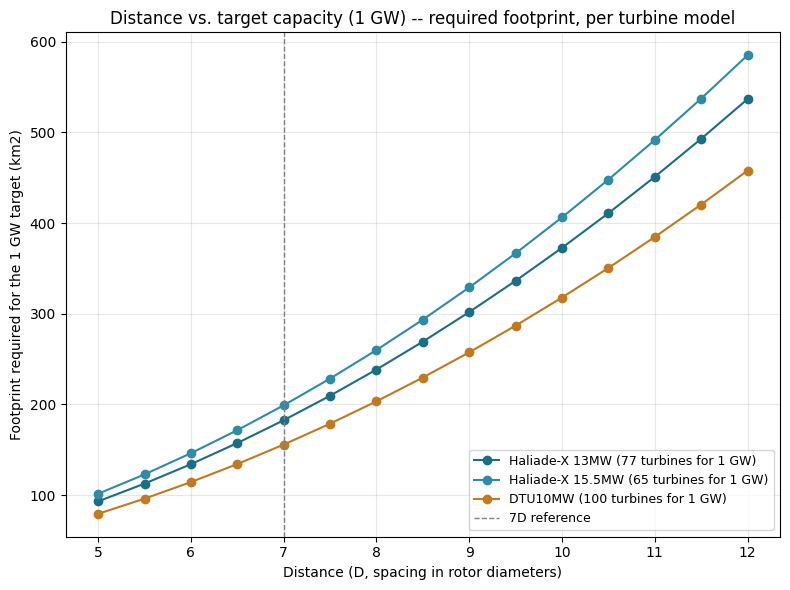

In [15]:
TARGET_CAPACITY_MW = 1000.0

fig, ax = plt.subplots(figsize=(8, 6))
for name, spec in TURBINES.items():
    n_needed = int(np.ceil(TARGET_CAPACITY_MW / spec["rated_mw"]))
    spacing_m = SPACING_D_RANGE * spec["diameter"]
    footprint_km2 = n_needed * spacing_m ** 2 / 1e6
    ax.plot(SPACING_D_RANGE, footprint_km2, "o-", color=COLORS[name], label=f"{name} ({n_needed} turbines for 1 GW)")

ax.axvline(7.0, color="gray", linestyle="--", linewidth=1, label="7D reference")
ax.set_xlabel("Distance (D, spacing in rotor diameters)")
ax.set_ylabel("Footprint required for the 1 GW target (km2)")
ax.set_title("Distance vs. target capacity (1 GW) -- required footprint, per turbine model")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "case2_speculative_target_footprint.png", dpi=180, bbox_inches="tight")
plt.show()

### 5.1 Wake field of the footprint samples (shared scale)

Each panel runs the Nygaard model on the actual bounding footprint for the 1 GW target at a given spacing, for one turbine, wind from the predominant sector (210 deg). All panels keep the same fixed axis extent and the same explicit flow-map grid, so both the footprint size and the wake pattern are directly comparable across spacing and turbine choice.

In [16]:
SAMPLE_SPACINGS_D = [5.0, 7.0, 9.0]

def footprint_layout(spec, spacing_d):
    n_needed = int(np.ceil(TARGET_CAPACITY_MW / spec["rated_mw"]))
    spacing_m = spacing_d * spec["diameter"]
    cols = int(np.ceil(np.sqrt(n_needed)))
    rows = int(np.ceil(n_needed / cols))
    xs = (np.arange(cols) - (cols - 1) / 2) * spacing_m
    ys = (np.arange(rows) - (rows - 1) / 2) * spacing_m
    gx, gy = np.meshgrid(xs, ys)
    pts = np.column_stack([gx.ravel(), gy.ravel()])[:n_needed]
    return pts, n_needed, cols, rows, spacing_m

GLOBAL_HALF_EXTENT_KM = max(
    np.abs(footprint_layout(spec, sd)[0]).max() / 1000
    for spec in TURBINES.values() for sd in SAMPLE_SPACINGS_D
) * 1.15

def plot_case2_wake(name, spec, fname):
    fig, axes = plt.subplots(1, len(SAMPLE_SPACINGS_D), figsize=(6 * len(SAMPLE_SPACINGS_D), 6))
    turbine_obj = build_pywake_turbine(TURBINE_FILES[name])
    single_type = WindTurbines.from_WindTurbine_lst([turbine_obj])
    grid_1d_m = np.linspace(-GLOBAL_HALF_EXTENT_KM * 1000, GLOBAL_HALF_EXTENT_KM * 1000, 200)

    for ax, sd in zip(axes, SAMPLE_SPACINGS_D):
        pts, n_needed, cols, rows, spacing_m = footprint_layout(spec, sd)
        wfm = Nygaard_2022(site, single_type)
        sim_snap = wfm(list(pts[:, 0]), list(pts[:, 1]), wd=[DOMINANT_WD], ws=[10])
        fmap = sim_snap.flow_map(grid=HorizontalGrid(x=grid_1d_m, y=grid_1d_m))
        fmap.plot_wake_map(ax=ax, cmap="inferno", normalize_with=1000, plot_windturbines=False)

        half_w, half_h = cols * spacing_m / 2000, rows * spacing_m / 2000
        area_km2 = (2 * half_w) * (2 * half_h)
        ax.plot([-half_w, half_w, half_w, -half_w, -half_w], [-half_h, -half_h, half_h, half_h, -half_h],
                "--", color="white", linewidth=1.0)
        ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=10, color="white", edgecolor="black", linewidth=0.2)
        ax.set_xlim(-GLOBAL_HALF_EXTENT_KM, GLOBAL_HALF_EXTENT_KM)
        ax.set_ylim(-GLOBAL_HALF_EXTENT_KM, GLOBAL_HALF_EXTENT_KM)
        ax.set_xlabel("x (km)")
        ax.set_ylabel("y (km)")
        ax.set_title(f"{sd:.0f}D -- {n_needed} turbines, {area_km2:.0f} km2")

    fig.suptitle(f"{name} -- wake field for 1 GW target across spacing, wind from {DOMINANT_WD} deg")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / fname, dpi=180, bbox_inches="tight")
    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


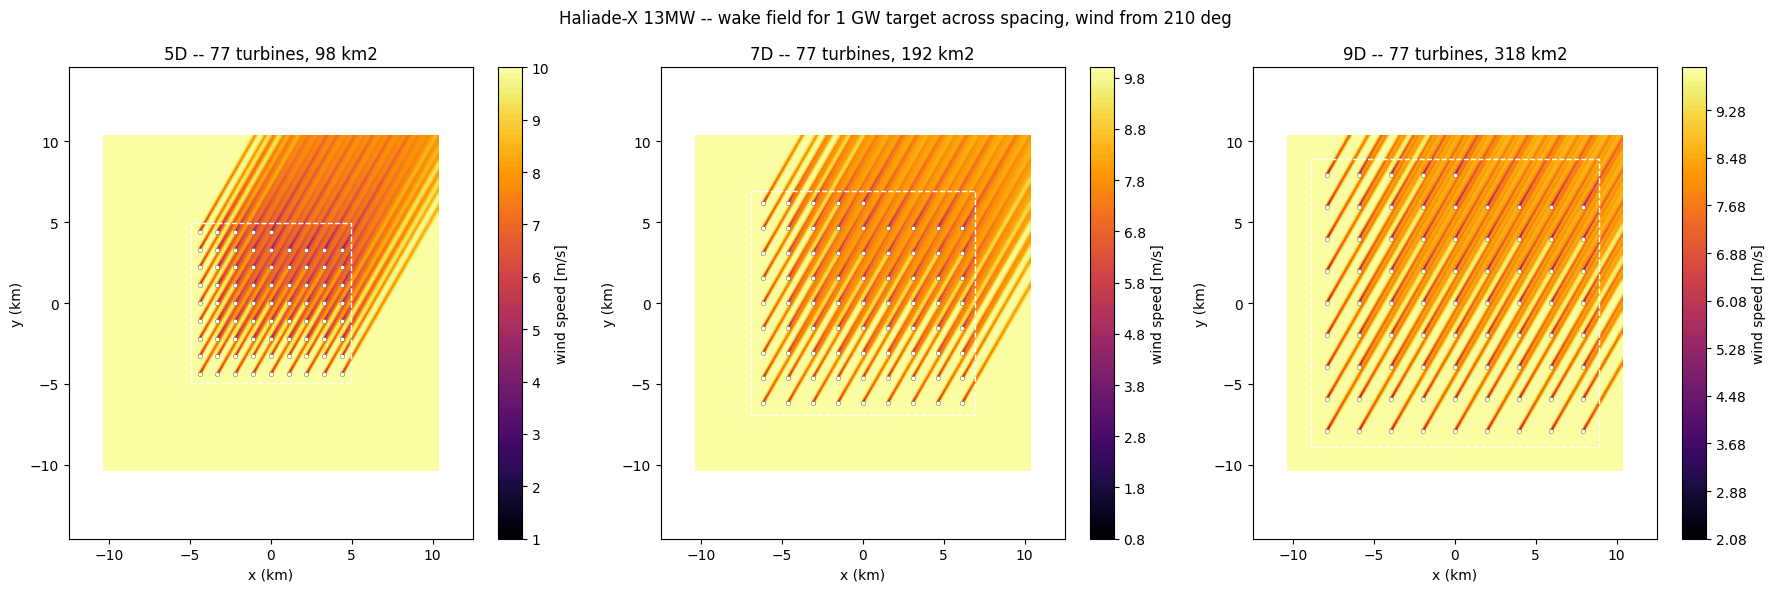

In [17]:
plot_case2_wake("Haliade-X 13MW", TURBINES["Haliade-X 13MW"], "case2_layout_haliade13.png")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


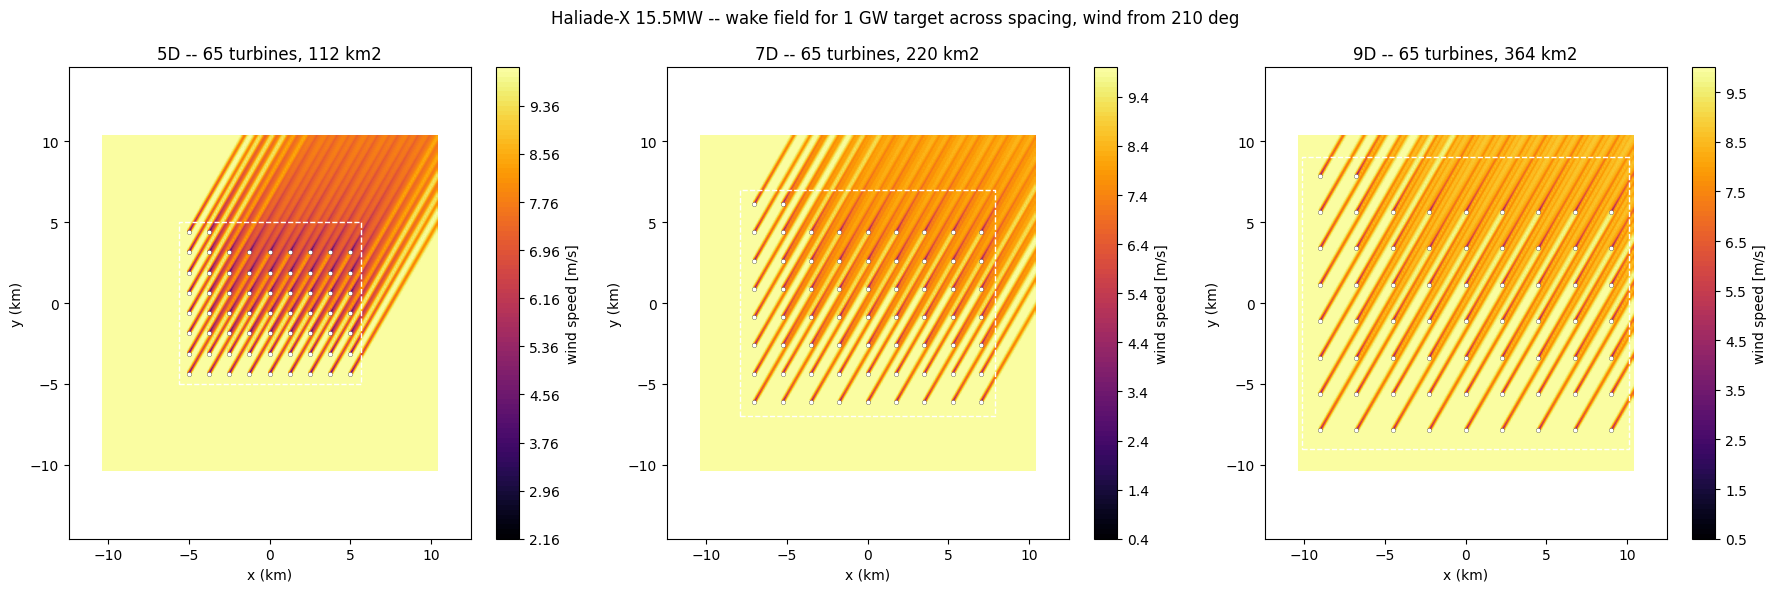

In [18]:
plot_case2_wake("Haliade-X 15.5MW", TURBINES["Haliade-X 15.5MW"], "case2_layout_haliade155.png")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


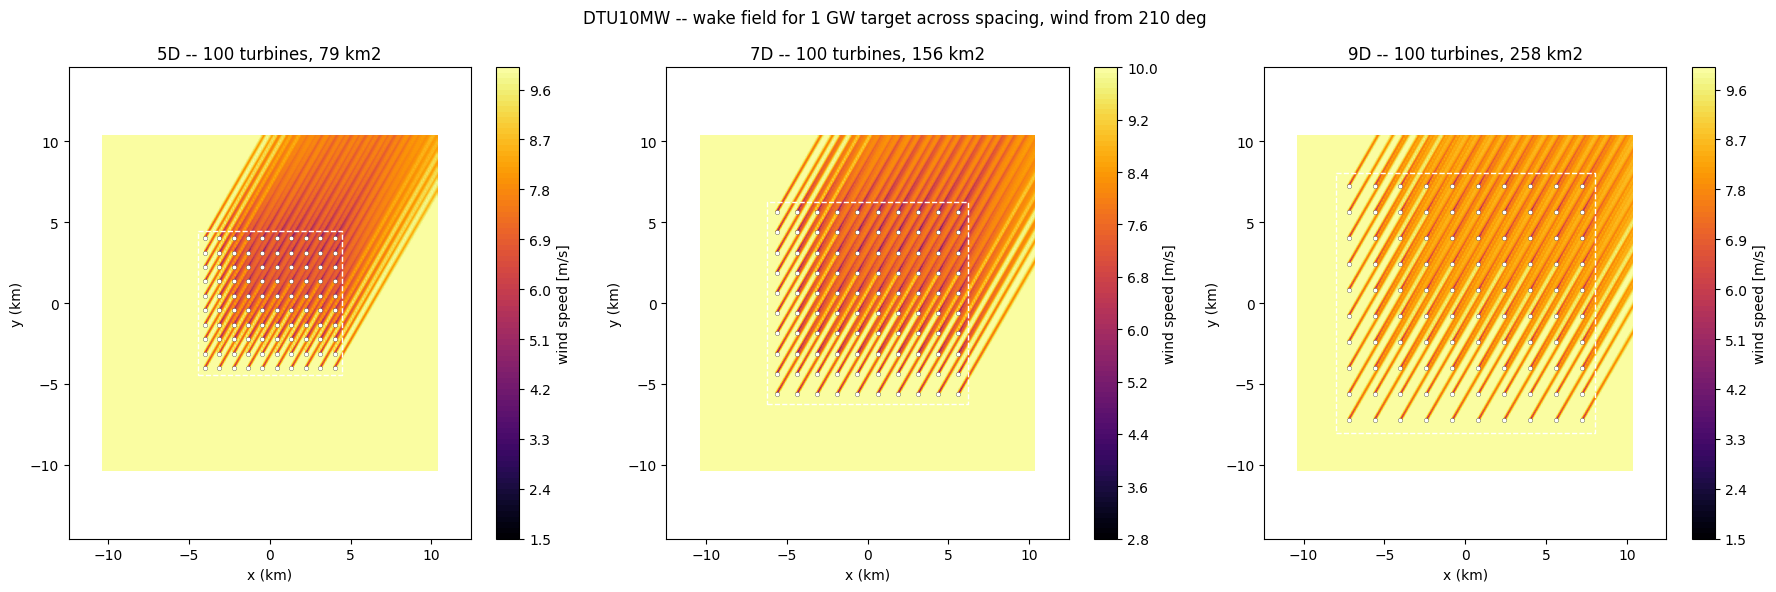

In [19]:
plot_case2_wake("DTU10MW", TURBINES["DTU10MW"], "case2_layout_dtu10mw.png")

### 5.2 Density power vs. distance (with physics)

Same nominal-vs-delivered comparison as 4.2, now for the speculative 1 GW footprint: nominal power density from geometry alone, against delivered energy density from the self-wake AEP of that same footprint. Still no neighboring farm -- only the speculative farm's own turbines.

In [20]:
density_results_case2 = {name: {"nominal": [], "delivered": []} for name in TURBINES}
for name, spec in TURBINES.items():
    turbine_obj = build_pywake_turbine(TURBINE_FILES[name])
    for sd in SPACING_D_RANGE:
        pts, n_needed, cols, rows, spacing_m = footprint_layout(spec, sd)
        area_km2 = (cols * spacing_m / 1000) * (rows * spacing_m / 1000)
        nominal_mw_km2 = n_needed * spec["rated_mw"] / area_km2
        aep_gwh, _ = compute_self_aep(pts[:, 0], pts[:, 1], turbine_obj)
        avg_power_mw = aep_gwh * 1000 / 8760
        delivered_mw_km2 = avg_power_mw / area_km2
        density_results_case2[name]["nominal"].append(nominal_mw_km2)
        density_results_case2[name]["delivered"].append(delivered_mw_km2)
    print(f"{name}: done")

Haliade-X 13MW: done


Haliade-X 15.5MW: done


DTU10MW: done


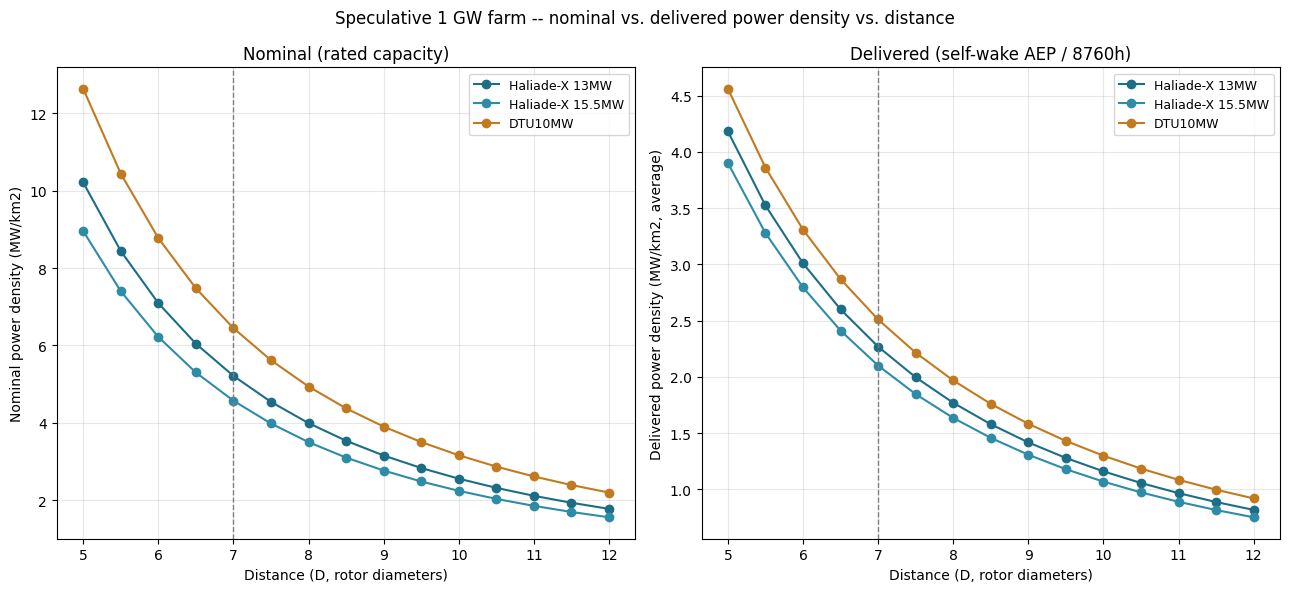

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for name in TURBINES:
    axes[0].plot(SPACING_D_RANGE, density_results_case2[name]["nominal"], "o-", color=COLORS[name], label=name)
    axes[1].plot(SPACING_D_RANGE, density_results_case2[name]["delivered"], "o-", color=COLORS[name], label=name)

for ax, ylabel, title in zip(axes, ["Nominal power density (MW/km2)", "Delivered power density (MW/km2, average)"],
                              ["Nominal (rated capacity)", "Delivered (self-wake AEP / 8760h)"]):
    ax.axvline(7.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Distance (D, rotor diameters)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Speculative 1 GW farm -- nominal vs. delivered power density vs. distance")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "case2_nominal_vs_delivered_density.png", dpi=180, bbox_inches="tight")
plt.show()